0     18.318371
1     20.788749
2     23.321069
3     25.692874
4     29.957111
5     34.187854
6     35.817505
7     38.350571
8     42.093357
9     41.708542
10    41.300733
11    43.043192
12    42.847805
13    43.774623
14    44.586640
15    42.985575
16    42.303077
17    41.007247
18    42.204642
19    43.710884
20    44.810880
21    44.750377
22    46.701102
23    49.273377
24    50.605531
25    51.842851
26    53.635075
27    54.262934
28    55.169782
29    57.183968
30    59.119053
31    60.294140
32    61.469643
33    60.496809
34    61.440111
35    62.533233
36    61.857038
37    61.658960
38    61.629123
39    62.471065
40    63.524178
41    63.358215
42    62.744912
43    61.585318
44    56.219909
45    59.837992
46    56.692077
47    56.158837
48    55.756172
49    54.312173
50    53.639298
51    52.956050
52    53.546774
53    53.165563
54    52.055369
55    48.252487
56    50.374815
57    50.048809
58    48.343737
dtype: float64


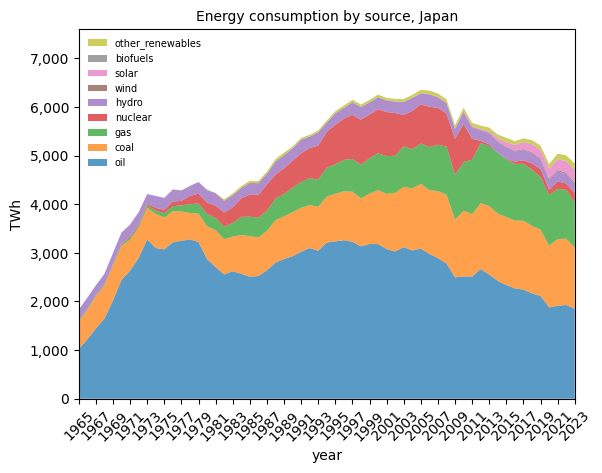

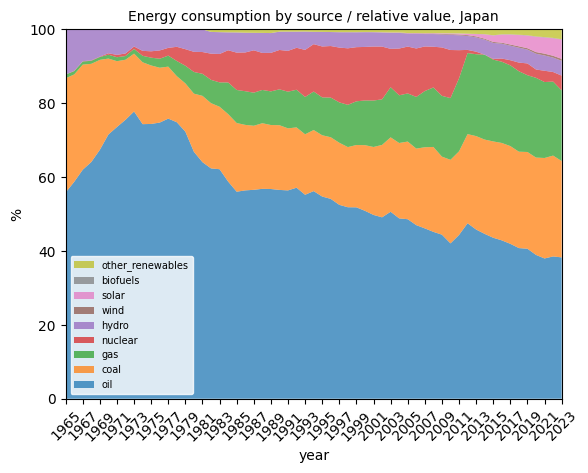

In [128]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

# Fetch the data. The User-Agent header is only necessary on google colab.
#df = pd.read_csv("https://ourworldindata.org/grapher/energy-consumption-by-source-and-country.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/電力源/Japan_consumption.csv')

df.columns = ['','index','Entity','Code','Year','other_renewables','biofuels',\
              'solar','wind','hydro','nuclear','gas','coal','oil']
cl = df.columns
#print(cl)


#print(len(cl))
s = df.iloc[:,5:].sum(axis=1)/100
print(s)

l = []
for i in range(len(cl)-1, 4, -1):
    l.append(cl[i])

a = np.full(9, 0.74)

#print(l)
# Graph 1. ---------------------------------------------------------------------------
fig, ax = plt.subplots()
plt.title('Energy consumption by source, Japan',fontsize=10)
plt.stackplot(df['Year'], df[cl[13]], df[cl[12]], df[cl[11]], df[cl[10]], df[cl[9]], \
              df[cl[8]], df[cl[7]],df[cl[6]], df[cl[5]], alpha=a, labels=l)
plt.xticks(df['Year'][::2], fontsize=10,rotation=45)
y = range(0, 6000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: '{:,}'.format(int(y))))
plt.yticks(fontsize=10)
plt.xlim(1965,2023)
plt.ylim(0, 7600)
plt.xlabel('year', fontsize=10)
plt.ylabel('TWh', fontsize=10)
handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
ax.legend(handles=handles[::-1],labels=labels[::-1],labelcolor="k",facecolor='w', edgecolor='w',\
           framealpha=0.8, ncol=1, loc='upper left', fontsize=7)# 判例を逆順に表示
#plt.legend(labelcolor="k",facecolor='w', edgecolor='w', framealpha=0.8, ncol=1, loc='upper left', fontsize=7)
plt.show()


# Graph 2. ---------------------------------------------------------------------------
fig, ax = plt.subplots()
plt.title('Energy consumption by source / relative value, Japan',fontsize=10)
"""
for i in range(len(df)):
    plt.stackplot(df['Year'], df.iloc[i, cl[13]]/s.iloc[i], \
                  df.iloc[i, cl[12]]/s.iloc[i], df.iloc[i, cl[11]]/s.iloc[i],\
                      df.iloc[i, cl[10]]/s.iloc[i], df.iloc[i, cl[9]]/s.iloc[i], \
                      df.iloc[i, cl[8]]/s.iloc[i], df.iloc[i, cl[7]]/s.iloc[i],\
                        df.iloc[i, cl[6]]/s.iloc[i], df.iloc[i,cl[5]]/s.iloc[i], labels=l)
"""
                        
plt.stackplot(df['Year'], df[cl[13]]/s, df[cl[12]]/s, df[cl[11]]/s,\
              df[cl[10]]/s, df[cl[9]]/s, df[cl[8]]/s, df[cl[7]]/s,\
              df[cl[6]]/s, df[cl[5]]/s, alpha=a,labels=l)

plt.xticks(df['Year'][::2], fontsize=10,rotation=45)
y = range(0, 100)
#plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: '{:,}'.format(int(y))))
plt.yticks(fontsize=10)
plt.xlim(1965,2023)
plt.ylim(0, 100)
plt.xlabel('year', fontsize=10)
plt.ylabel('%', fontsize=10)
handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
ax.legend(handles=handles[::-1],labels=labels[::-1],labelcolor="k",facecolor='w', edgecolor='w',\
           framealpha=0.8, ncol=1, loc='lower left', fontsize=7)# 判例を逆順に表示
#plt.legend(labelcolor="k",facecolor='w', edgecolor='w', framealpha=0.8, ncol=1, loc='upper left', fontsize=7)
plt.show()
